In [1]:
# import all required packages
import corgietc
import os
import json
import EXOSIMS.Prototypes.TargetList
import EXOSIMS.Prototypes.TimeKeeping
import copy
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# This loads the default input specification
scriptfile = os.path.join(os.environ["CORGIETC_DATA_DIR"], "scripts", "CGI_Noise.json")
with open(scriptfile, "r") as f:
    specs = json.loads(f.read())

In [3]:
TL = EXOSIMS.Prototypes.TargetList.TargetList(**copy.deepcopy(specs))
OS = TL.OpticalSystem
ZL = TL.ZodiacalLight
mode = OS.observingModes[0]
mode2 = OS.observingModes[0].copy()
mode2["theta"] = np.pi/4
sInds = 0
JEZ = TL.JEZ0[mode["hex"]]/(4.1536**2)
fZ = np.repeat(TL.ZodiacalLight.fZ0, 1)
contrast = 1e-7
dMag = np.array([(-2.5) * np.log10(contrast)])
# dMag = np.array([20]) #contrast : 1e-8
WA = np.array([7.5]) * (mode["lam"]/OS.pupilDiam).to(u.arcsec, equivalencies=u.dimensionless_angles())

/Users/saanikachoudhary/Desktop/EXOSIMS/EXOSIMS/Prototypes/TargetList.py:379: UserWarning: binary_filter is None but filterBinaries is False. Using binary_filter value of None.
  warnings.warn(


Imported StarCatalog (prototype) from EXOSIMS.Prototypes.StarCatalog
Imported corgietc (named file) from /Users/saanikac[...]ietc/corgietc/corgietc.py
Imported Stark (implementation) from EXOSIMS.ZodiacalLight.Stark
Imported PostProcessing (prototype) from EXOSIMS.Prototypes.PostProcessing
Imported GalaxiesFaintStars (implementation) from EXOSIMS.BackgroundSources.GalaxiesFaintStars
Imported Completeness (prototype) from EXOSIMS.Prototypes.Completeness
Imported PlanetPopulation (prototype) from EXOSIMS.Prototypes.PlanetPopulation
Imported ForecasterMod (implementation) from EXOSIMS.PlanetPhysicalModel.ForecasterMod
1 targets imported from star catalog.
1 targets remain after removing those where spectral class cannot be established.
1 targets remain after removing white dwarfs and subdwarfs
1 targets remain after nan filtering.
1 targets remain after removing zero luminosity targets.
Loaded JEZ0 for mode ad0f6cb53a8464731e105f381f68d63a from /Users/saanikachoudhary/.EXOSIMS/cache/v3.6.

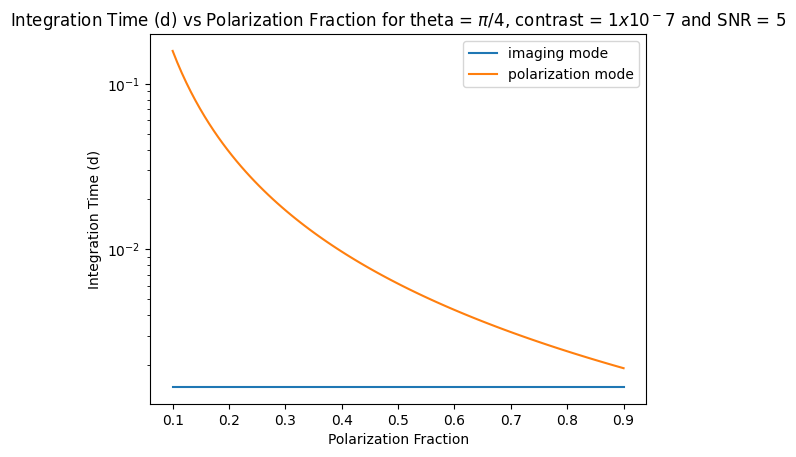

In [4]:
ps = np.linspace(0.1, 0.9, 100)
times_int = np.zeros(len(ps))*u.d
times_p = np.zeros(len(ps))*u.d
for j, p in enumerate(ps):
    mode2["polfraction"] = p
    times_int[j] = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode)[0]
    times_p[j] = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode2)[0]

plt.figure()
plt.semilogy(ps, times_int, label = 'imaging mode')
plt.semilogy(ps, times_p, label = 'polarization mode')
plt.xlabel(rf"Polarization Fraction")
plt.ylabel(f"Integration Time ({times_int.unit})")
plt.title(rf"Integration Time (d) vs Polarization Fraction for theta = $\pi/4$, contrast = $1 x 10^{-7}$ and SNR = 5")
plt.legend()
plt.show()

In [5]:
mode2["polfraction"] = 1
time_int = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode)[0]
time_p = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode2)[0]
print(time_int)
print(time_p)
print(time_p - time_int)

0.0014687525617378364 d
0.0015439651763980058 d
7.52126146601694e-05 d


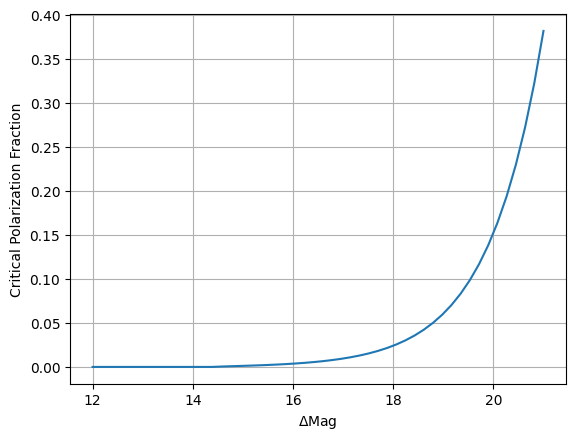

In [6]:
dMags = np.linspace(12, 21, 50)
p_crit = []
for i in range(len(dMags)):
    p_crit.append(OS.calc_critical_polfraction(TL, sInds, fZ, JEZ, dMags[i], WA, mode2, TK=None))
plt.figure()
plt.plot(dMags, p_crit)
plt.xlabel(rf"$\Delta$Mag")
plt.ylabel(f"Critical Polarization Fraction")
plt.grid()
plt.show()

In [7]:
ps = np.linspace(0.1, 0.3, 3)
times_int1 = np.zeros(len(ps))*u.d
times_p1 = np.zeros(len(ps))*u.d
for j, p in enumerate(ps):
    # mode["polfraction"] = p
    mode2["polfraction"] = p
    times_int1[j] = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode)[0]
    times_p1[j] = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode2)[0]

In [8]:
mode2["Cp_ab"] = 1e-9
times_int2 = np.zeros(len(ps))*u.d
times_p2 = np.zeros(len(ps))*u.d
for j, p in enumerate(ps):
    # mode["polfraction"] = p
    mode2["polfraction"] = p
    times_int2[j] = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode)[0]
    times_p2[j] = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode2)[0]

In [9]:
times_int_combined = np.concatenate([times_int1, times_int2])
times_p_combined = np.concatenate([times_p1, times_p2])

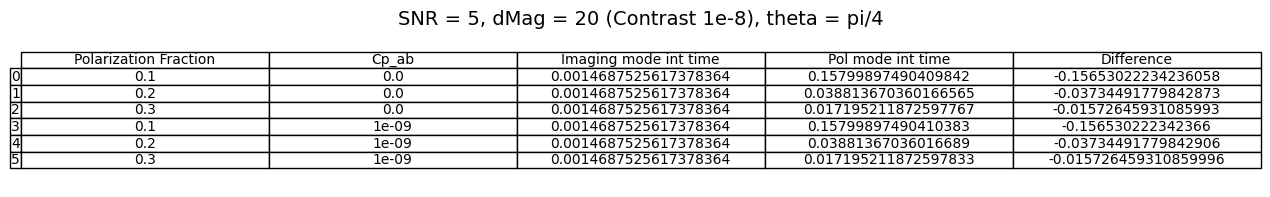

In [10]:
df = pd.DataFrame({"Polarization Fraction": np.concatenate([ps, ps]), 
                   "Cp_ab": [0,0,0,1e-9, 1e-9, 1e-9],
                   "Imaging mode int time": times_int_combined, 
                   "Pol mode int time": times_p_combined, 
                   "Difference": times_int_combined - times_p_combined})

fig, ax = plt.subplots(figsize=(16, 2))

ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc='center',
    cellLoc='center'
)

ax.set_title('SNR = 5, dMag = 20 (Contrast 1e-8), theta = pi/4', fontsize=14) 

plt.show()

In [11]:
# C_p, C_b, C_sp = OS.Cp_Cb_Csp(TL, sInds, fZ, JEZ, dMag, WA, mode)
# _C_p = C_p.to_value(1/u.s)
# _C_b = C_b.to_value(1/u.s)
# _C_sp = C_sp.to_value(1/u.s)

In [12]:
# SNR = mode["SNR"]
# inst = mode["inst"]
# p_in = 0.2
# theta_in = np.pi/4

In [13]:
# Pol0 = _C_p*96.2
# Pol45 = _C_p*96.5

# I0 = Pol0/2*(1+p_in*np.cos(2*theta_in))
# I90 = Pol0/2*(1-p_in*np.cos(2*theta_in))
# I45 = Pol45/2*(1+p_in*np.sin(2*theta_in))
# I135 = Pol45/2*(1-p_in*np.sin(2*theta_in))

# I_in = (I0 + I90 + I45 + I135)/2
# Q_in = I0 - I90
# U_in = I45 - I135
# mat = np.array([I_in, Q_in, U_in, [0]])
# in_mat = mode["inst"]["matrix"]@mat
# I_m = in_mat[0] 
# Q_m = -in_mat[1]
# U_m = in_mat[2]
# print(I_m)

# p_f = np.sqrt(Q_m**2 + U_m**2)/I_m
# print(p_f)
# theta_f = 0.5*(np.arctan(U_m/Q_m)*180/np.pi)

# intTime = np.true_divide(SNR**2.0 * _C_b,((_C_p * p_f) ** 2.0 - (SNR * (_C_sp)) ** 2.0),)
# print(intTime)

In [14]:
# Pol0 = _C_p*96.2
# Pol45 = _C_p*96.5

# I0 = Pol0/2*(1+p_in*np.cos(2*theta_in)) #confirm formula
# I90 = Pol0/2*(1-p_in*np.cos(2*theta_in))
# I45 = Pol45/2*(1+p_in*np.sin(2*theta_in))
# I135 = Pol45/2*(1-p_in*np.sin(2*theta_in))

# I_in = (I0 + I90 + I45 + I135)/2
# Q_in = I0 - I90
# U_in = I45 - I135
# mat = np.array([I_in, Q_in, U_in, [0]])
# in_mat = inst["matrix"]@mat
# I_m = in_mat[0]
# Q_m = -in_mat[1]
# U_m = in_mat[2]

# p_f = np.sqrt(Q_m**2 + U_m**2)/I_m
# theta_f = 0.5*(np.arctan(U_m/Q_m)*180/np.pi) 

In [15]:
# intTime = (np.true_divide(SNR**2.0 * _C_b,((_C_p * p_f) ** 2.0 - (SNR * _C_sp) ** 2.0)))/86400
# intTime

In [16]:

# n = 1 #confirm 
# A = I_m
# B = Q_m
# C = U_m
# Ae = _C_b * (I0 + I90 + I45 + I135)
# De = _C_sp**2.0 # confirm if C_sp
# Be = _C_b * (I0 + I90)
# Bq = 0 #to be edited later
# Ce = _C_b * (I45 + I135)
# Cu = 0 #to be edited later
# R_p = SNR * p_f #confirm formula
# S1 = R_p**2*B**2*Be + R_p**2*C**2*Ce 
# S2 = B**2*Bq*R_p**2 + C**2*Cu*R_p**2 + A**2*p_f**2*De*R_p**2 - p_f**4*n**2*A**4
# S3 = p_f**2*A**2*Ae*R_p**2

# print(S2**2)
# print(4*S1*S3)

# # intTime = (np.sqrt(S2**2 - 4*S1*S3) - S2)/(2*S1)
# # intTime

In [17]:
# Pol0 = C_p*96.2
# Pol45 = C_p*96.5
# p_in = 0.5
# theta_in = np.pi/3
# p_in = p_in if isinstance(p_in, list) else [p_in]
# theta_in = theta_in if isinstance(theta_in, list) else [theta_in]
# I0 = C_p*Pol0/2*(1+p_in*np.cos(2*theta_in))
# I90 = C_p*Pol0/2*(1-p_in*np.cos(2*theta_in))
# I45 = C_p*Pol45/2*(1+p_in*np.sin(2*theta_in))
# I135 = C_p*Pol45/2*(1-p_in*np.sin(2*theta_in))

# I_in = (I0 + I90 + I45 + I135)/2
# Q_in = I0 - I90
# U_in = I45 - I135
# mat = []
# for i in range(len(p_in)):
#     mat.append(np.array([[I_in[i]], [Q_in[i]], [U_in[i]], [0]]))
# in_mat = inst["matrix"]@mat
# I_m = []
# Q_m = []
# U_m = []
# V_m = []
# for i in range(len(p_in)):
#     I_m.append(in_mat[i][0][0])
#     Q_m.append(in_mat[i][1][0])
#     U_m.append(in_mat[i][2][0])
#     V_m.append(in_mat[i][3][0])

# I_m = np.array(I_m)
# Q_m = -np.array(Q_m)
# U_m = np.array(U_m)

# p_f = np.sqrt(Q_m**2 + U_m**2)/I_m
# theta_f = 0.5*(np.arctan(U_m/Q_m)*180/np.pi) 